# Block 3 — Canonical ECAL Event Model

This notebook validates the canonical event representation introduced in Block 3.

A canonical event combines:

- particle truth;
- primary energy;
- reconstructed tracker state;
- ECAL geometry;
- an alternating-readout energy grid;
- reproducibility metadata.

The native calorimeter representation is

$$
\mathbf{E}
\in
\mathbb{R}_{\geq 0}^{18 \times 72},
$$

where each row represents one longitudinal ECAL readout layer and each
column represents one cell in that layer.

This is not a dense three-dimensional voxel image. Each layer measures one
transverse coordinate according to its fiber orientation.

In [1]:
from hashlib import sha256
from pathlib import Path

import matplotlib.pyplot as plt

from ams_ecal import (
    ECALEvent,
    EventProvenance,
    TrackState,
    load_geometry,
    project_track_to_cell_indices,
)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

CONFIG_PATH = PROJECT_ROOT / "configs" / "geometry.yaml"

geometry = load_geometry(CONFIG_PATH)

print("Project root:", PROJECT_ROOT)
print("Geometry config:", CONFIG_PATH)
print("Number of layers:", geometry.number_of_layers)
print("Cells per layer:", geometry.cells_per_layer)

Project root: C:\Users\ASUS\ams-ecal-qml
Geometry config: C:\Users\ASUS\ams-ecal-qml\configs\geometry.yaml
Number of layers: 18
Cells per layer: 72


## Constructing a diagnostic event

Block 3 does not yet generate a physical electromagnetic or hadronic shower.
That work begins in Block 4.

For this notebook, we construct a deterministic diagnostic energy grid. In each
layer, a single energy deposit is placed in the cell crossed by the projected
track.

The layer energy is defined only for testing as

$$
E_\ell = \ell + 1\ \mathrm{MeV},
$$

where $\ell$ is the zero-based layer index.

This artificial pattern allows us to verify:

- track projection;
- alternating readout;
- event-grid dimensions;
- layer-energy calculation;
- total-energy calculation.

It must not be interpreted as a physical shower model.

In [2]:
track = TrackState(
    x0_mm=22.4,
    y0_mm=-17.2,
    z0_mm=0.0,
    theta_rad=0.0,
    phi_rad=0.0,
)

print("Track:", track)
print("Direction:", track.direction_unit_vector)
print("Slopes with respect to z:", track.slopes_wrt_z)

Track: TrackState(x0_mm=22.4, y0_mm=-17.2, z0_mm=0.0, theta_rad=0.0, phi_rad=0.0)
Direction: (0.0, 0.0, 1.0)
Slopes with respect to z: (0.0, 0.0)


In [3]:
projected_cells = project_track_to_cell_indices(
    track,
    geometry,
)

mutable_energy_grid = [
    [0.0 for _ in range(geometry.cells_per_layer)]
    for _ in range(geometry.number_of_layers)
]

for layer_index, cell_index in enumerate(projected_cells):
    if cell_index is not None:
        mutable_energy_grid[layer_index][cell_index] = float(
            layer_index + 1
        )

cell_energies_mev = tuple(
    tuple(layer_energies)
    for layer_energies in mutable_energy_grid
)

print("Grid rows:", len(cell_energies_mev))
print("Cells in first row:", len(cell_energies_mev[0]))
print("Projected cells:", projected_cells)

Grid rows: 18
Cells in first row: 72
Projected cells: (34, 34, 38, 38, 34, 34, 38, 38, 34, 34, 38, 38, 34, 34, 38, 38, 34, 34)


## Configuration provenance

Every simulated event stores a cryptographic hash of the configuration used to
produce it.

For a configuration file with byte contents $C$, the stored identifier is

$$
h = \operatorname{SHA256}(C).
$$

If the geometry or simulation configuration changes, its hash also changes.
This allows datasets produced with different assumptions to be distinguished
even when their filenames are similar.

In [4]:
configuration_sha256 = sha256(
    CONFIG_PATH.read_bytes()
).hexdigest()

provenance = EventProvenance(
    simulation_backend="fastmc",
    simulation_version="0.1.0",
    configuration_sha256=configuration_sha256,
    random_seed=12345,
)

print("Configuration SHA-256:", configuration_sha256)
print("Provenance:", provenance)

Configuration SHA-256: 203758a3472f194329463821dfd738e76803ba9de873c801258def95b5b9e7d9
Provenance: EventProvenance(simulation_backend='fastmc', simulation_version='0.1.0', configuration_sha256='203758a3472f194329463821dfd738e76803ba9de873c801258def95b5b9e7d9', random_seed=12345)


In [5]:
event = ECALEvent(
    event_id="diagnostic-event-000001",
    particle_type="electron",
    primary_energy_mev=100_000.0,
    track=track,
    geometry=geometry,
    cell_energies_mev=cell_energies_mev,
    provenance=provenance,
)

event

ECALEvent(event_id='diagnostic-event-000001', particle_type='electron', primary_energy_mev=100000.0, track=TrackState(x0_mm=22.4, y0_mm=-17.2, z0_mm=0.0, theta_rad=0.0, phi_rad=0.0), geometry=ECALGeometry(width_x_mm=648.0, width_y_mm=648.0, depth_z_mm=166.5, number_of_superlayers=9, number_of_layers=18, cells_per_layer=72, cell_pitch_mm=9.0, superlayer_fiber_axes=('x', 'y', 'x', 'y', 'x', 'y', 'x', 'y', 'x'), total_depth_x0=17.0, total_depth_lambda_i=0.6, origin='front_face_center', positive_z_direction='into_ecal', theta_reference_axis='positive_z'), cell_energies_mev=((0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0), (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 

## Primary energy versus ECAL energy

The primary energy and measured ECAL energy are different quantities.

The primary energy is the incident-particle energy:

$$
E_{\mathrm{primary}}.
$$

The ECAL energy is the sum of all recorded cell energies:

$$
E_{\mathrm{ECAL}}
=
\sum_{\ell=0}^{17}
\sum_{c=0}^{71}
E_{\ell c}.
$$

For this diagnostic event,

$$
E_{\mathrm{ECAL}}
=
\sum_{\ell=0}^{17}(\ell+1)
=
171\ \mathrm{MeV}.
$$

The diagnostic ECAL energy is intentionally much smaller than the chosen primary
energy because this notebook is validating the data structure, not simulating
energy conservation or detector response.

In [6]:
print("Event ID:", event.event_id)
print("Particle:", event.particle_type)
print("Primary energy:", event.primary_energy_mev, "MeV")
print("ECAL energy:", event.total_ecal_energy_mev, "MeV")
print("Schema version:", event.schema_version)

print("\nLayer energies:")
for layer_index, energy_mev in enumerate(event.layer_energies_mev):
    print(f"Layer {layer_index:2d}: {energy_mev:5.1f} MeV")

Event ID: diagnostic-event-000001
Particle: electron
Primary energy: 100000.0 MeV
ECAL energy: 171.0 MeV
Schema version: 1

Layer energies:
Layer  0:   1.0 MeV
Layer  1:   2.0 MeV
Layer  2:   3.0 MeV
Layer  3:   4.0 MeV
Layer  4:   5.0 MeV
Layer  5:   6.0 MeV
Layer  6:   7.0 MeV
Layer  7:   8.0 MeV
Layer  8:   9.0 MeV
Layer  9:  10.0 MeV
Layer 10:  11.0 MeV
Layer 11:  12.0 MeV
Layer 12:  13.0 MeV
Layer 13:  14.0 MeV
Layer 14:  15.0 MeV
Layer 15:  16.0 MeV
Layer 16:  17.0 MeV
Layer 17:  18.0 MeV


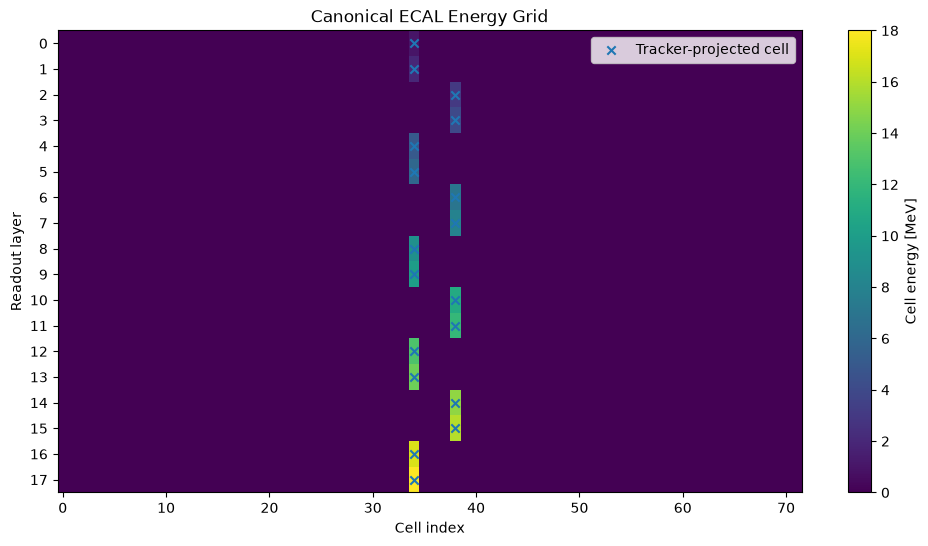

In [7]:
figure, axis = plt.subplots(figsize=(12, 6))

image = axis.imshow(
    event.cell_energies_mev,
    aspect="auto",
    interpolation="nearest",
)

valid_layers = [
    layer_index
    for layer_index, cell_index in enumerate(
        event.projected_cell_indices
    )
    if cell_index is not None
]

valid_cells = [
    cell_index
    for cell_index in event.projected_cell_indices
    if cell_index is not None
]

axis.scatter(
    valid_cells,
    valid_layers,
    marker="x",
    label="Tracker-projected cell",
)

axis.set_title("Canonical ECAL Energy Grid")
axis.set_xlabel("Cell index")
axis.set_ylabel("Readout layer")
axis.set_yticks(range(geometry.number_of_layers))
axis.legend()

colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("Cell energy [MeV]")

plt.show()

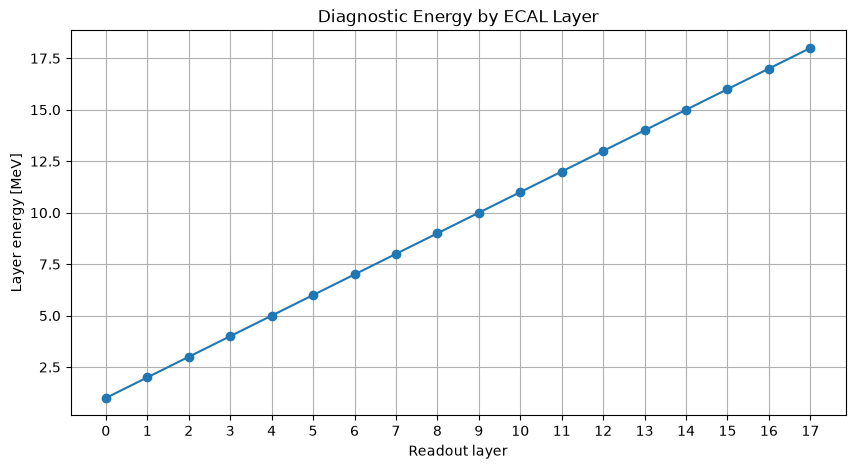

In [8]:
figure, axis = plt.subplots(figsize=(10, 5))

axis.plot(
    range(geometry.number_of_layers),
    event.layer_energies_mev,
    marker="o",
)

axis.set_title("Diagnostic Energy by ECAL Layer")
axis.set_xlabel("Readout layer")
axis.set_ylabel("Layer energy [MeV]")
axis.set_xticks(range(geometry.number_of_layers))
axis.grid()

plt.show()

## Canonical-event invariants

Every valid canonical event satisfies the following structural conditions.

### Grid shape

$$
\operatorname{shape}(\mathbf{E})
=
(N_{\mathrm{layers}}, N_{\mathrm{cells}})
=
(18,72).
$$

### Energy domain

$$
E_{\ell c} \geq 0
$$

for every layer $\ell$ and cell $c$.

### Tracker projection

The projected track-cell sequence contains one entry per layer:

$$
(c_0,c_1,\ldots,c_{17}),
$$

where each entry is either a valid cell index or `None`.

`None` represents a projected track position outside the active readout grid.

### Reproducibility

Each event records:

- simulation backend;
- simulation version;
- configuration hash;
- random seed.

The canonical event therefore separates stable event structure from the physics
model that generated the event.

In [9]:
assert len(event.cell_energies_mev) == geometry.number_of_layers

assert all(
    len(layer_energies) == geometry.cells_per_layer
    for layer_energies in event.cell_energies_mev
)

assert all(
    energy_mev >= 0.0
    for layer_energies in event.cell_energies_mev
    for energy_mev in layer_energies
)

assert len(event.projected_cell_indices) == geometry.number_of_layers

assert event.layer_energies_mev == tuple(
    float(layer_index + 1)
    for layer_index in range(geometry.number_of_layers)
)

assert event.total_ecal_energy_mev == 171.0

assert event.provenance.configuration_sha256 == configuration_sha256

print("All canonical-event validation checks passed.")

All canonical-event validation checks passed.


## Block 3 result

The repository now has one stable event representation that can be produced by
multiple simulation backends.

Future FastMC and Geant4 code will both produce `ECALEvent` objects containing
the same core fields and the same $18 \times 72$ energy-grid convention.

Block 3 deliberately does not define:

- electromagnetic shower development;
- hadronic shower development;
- random event generation;
- detector noise;
- thresholds or saturation;
- track-centered cropping;
- normalized ML inputs;
- binary classification labels;
- dataset serialization.

These responsibilities belong to later blocks.

The next implementation block is **Block 4 — longitudinal electromagnetic
shower profile**.